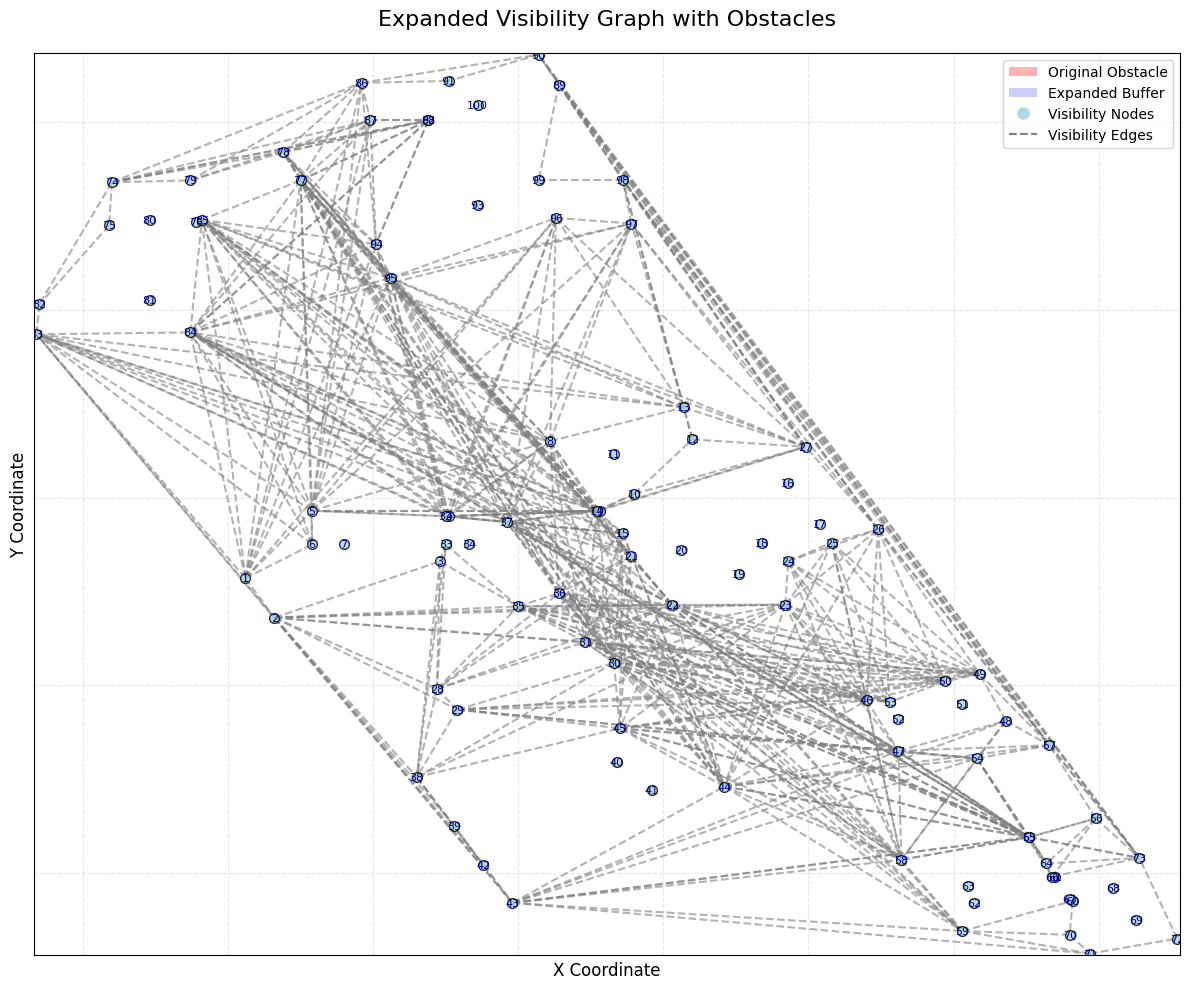

In [2]:
import json
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.collections import PatchCollection
import numpy as np

# 1. 读取JSON文件
with open('buildings_visibility_graph.json', 'r') as f:
    data = json.load(f)

# 2. 创建图形
G = nx.Graph()

# 3. 添加节点
for node in data['nodes']:
    node_id = node['id']
    pos = node['bar']
    G.add_node(node_id, pos=pos)

# 4. 添加边
for link in data['links']:
    source = link['source']
    target = link['target']
    weight = link['foo']
    G.add_edge(source, target, weight=weight)

# 5. 获取节点位置
pos = nx.get_node_attributes(G, 'pos')

# 6. 创建图形
plt.figure(figsize=(12, 10))



# 9. 绘制网络
nx.draw_networkx_nodes(G, pos, node_size=50, node_color='lightblue', 
                      alpha=0.8, edgecolors='black', linewidths=1)

nx.draw_networkx_edges(G, pos, edge_color='gray', alpha=0.6, 
                      width=1.5, style='dashed')

nx.draw_networkx_labels(G, pos, font_size=8, font_color='darkblue')

# 10. 添加图例和标题
plt.title('Expanded Visibility Graph with Obstacles', fontsize=16, pad=20)
plt.xlabel('X Coordinate', fontsize=12)
plt.ylabel('Y Coordinate', fontsize=12)

# 创建自定义图例
from matplotlib.lines import Line2D
legend_elements = [
    patches.Patch(facecolor='red', alpha=0.3, label='Original Obstacle'),
    patches.Patch(facecolor='blue', alpha=0.2, label='Expanded Buffer'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='lightblue', 
           markersize=10, label='Visibility Nodes'),
    Line2D([0], [0], color='gray', linestyle='dashed', label='Visibility Edges')
]

plt.legend(handles=legend_elements, loc='upper right')

# 11. 设置坐标轴范围
all_x = [pos[0] for pos in pos.values()]
all_y = [pos[1] for pos in pos.values()]
plt.xlim(min(all_x) - 1, max(all_x) + 1)
plt.ylim(min(all_y) - 1, max(all_y) + 1)

# 12. 添加网格
plt.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()